# Diffrax example

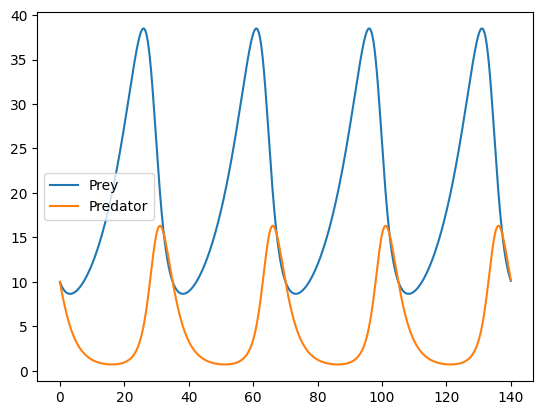

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ODETerm, SaveAt, Tsit5, BacksolveAdjoint

def vector_field(t, y, args):
    prey, predator = y
    α, β, γ, δ = args
    d_prey = α * prey - β * prey * predator
    d_predator = -γ * predator + δ * prey * predator
    d_y = d_prey, d_predator
    return d_y


term = ODETerm(vector_field)
solver = Tsit5()
t0 = 0
t1 = 140
dt0 = 0.1
y0 = (10.0, 10.0)
args = (0.1, 0.02, 0.4, 0.02)
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
sol = diffeqsolve(term, solver, t0, t1, dt0, y0, args=args, saveat=saveat)

plt.plot(sol.ts, sol.ys[0], label="Prey")
plt.plot(sol.ts, sol.ys[1], label="Predator")
plt.legend()
plt.show()

# Setup Bayesian inference with auto-differentiable diff equ solver as forward model

In [3]:
from diffrax import diffeqsolve, ODETerm, SaveAt, Tsit5
import jax
from jax import lax
jax.config.update("jax_enable_x64", True)
import nifty.nifty.re as jft
from diffrax import LinearInterpolation
# from phase_II.nifty_re_playground.useful.helpers import *
key = jax.random.PRNGKey(42)
import numpy as np

In [4]:
path1 = "/Users/iason/PycharmProjects/STRAIN/data/data_txt/num_rel_template_strain_values.txt"
path2 = "/Users/iason/PycharmProjects/STRAIN/data/data_txt/num_rel_template_time_values.txt"
gw_waveform = np.loadtxt(path1)
gw_waveform /= max(gw_waveform)
gw_times = np.loadtxt(path2)
gw_times = gw_times-gw_times[0]

In [5]:
def create_cfm(downsampled_times, prefix, offset_std, offset_mean, fluct, llslope, flex=None):
    """

    :param downsampled_times:   To speed up the solving of the differential equation, when using an adaptive step size
                                solver, the times may be chosen quite coarse in order to not force very small steps. Further,
                                since the adaptive step size method may require evaluation in between the support points, a
                                linear interpolator must be used at some point.
    :param prefix:              The model prefix.
    :param offset_std:
    :param fluct:
    :param llslope:
    :return:
    """
    N = len(downsampled_times)
    dt = downsampled_times[1]-downsampled_times[0]
    cfm_maker = jft.CorrelatedFieldMaker(prefix=prefix)
    cfm_maker.set_amplitude_total_offset(offset_mean=offset_mean, offset_std=offset_std)
    cfm_maker.add_fluctuations(shape=N, distances=dt, fluctuations=fluct, loglogavgslope=llslope,
                               flexibility=flex, non_parametric_kind="power", harmonic_type="fourier")
    correlated_field = cfm_maker.finalize()
    return correlated_field


def stochastic_differential_equation(t, y, args):
    """
    Call (t,y args) where args = (omega_interpol, gamma_interpol, xi_interpol).

    :param t:                               The current/next time step to solve for.
    :param y:                               The current state vector (waveform and its derivative).
    :return:
    """
    h, u = y
    omega_interpol, gamma_interpol, xi_interpol = args
    omega_i, gamma_i, xi_i = (f.evaluate(t) for f in (omega_interpol, gamma_interpol, xi_interpol))

    dh_dt = u
    du_dt = xi_i - gamma_i * u - omega_i**2 * h
    return jnp.array([dh_dt, du_dt])


def diffrax_solver(sampling_times, reconstruction_times):
    """
    :TODO Only call diffeqsolve here, not the whole setup as well.
    :param sampling_times: jnp.array,     the time support points of the data.
    :return: A solver object that needs an arg list (not unpacked) as input
    """
    vector_field = ODETerm(stochastic_differential_equation)

    solver = Tsit5()
    t0 = sampling_times.min()
    t1 = sampling_times.max()
    dt0 = sampling_times[1]-sampling_times[0]
    saveat = SaveAt(ts=reconstruction_times)

    def sol(args):
        return diffeqsolve(vector_field, solver, t0, t1, dt0=dt0, args=args, y0=jnp.array([.0,.0]), saveat=saveat, max_steps=2*4096)

    return sol


def rk2_solver(times, omega, gamma, xi):
    dt = times[1] - times[0]

    def step(state, params):
        h, u = state
        ω, γ, ξ = params

        # k1
        dh1 = u
        du1 = ξ - γ*u - ω**2*h

        # midpoint
        h_mid = h + 0.5*dt*dh1
        u_mid = u + 0.5*dt*du1

        # k2
        dh2 = u_mid
        du2 = ξ - γ*u_mid - ω**2*h_mid

        h_new = h + dt*dh2
        u_new = u + dt*du2

        return (h_new, u_new), h_new

    params = jnp.stack([omega, gamma, xi], axis=1)

    init = (0.0, 0.0)
    (_, _), h_traj = jax.lax.scan(step, init, params)

    return h_traj


def symplectic_euler(times, omega, gamma, xi):
    dt = times[1] - times[0]

    def step(state, params):
        h, u = state
        ω, γ, ξ = params

        u_new = u + dt*(ξ - γ*u - ω**2*h)
        h_new = h + dt*u_new
        return (h_new, u_new), h_new

    params = jnp.stack([omega, gamma, xi], axis=1)
    (_, _), h_traj = jax.lax.scan(step, (0.0, 0.0), params)
    return h_traj




class AutoDiffEquationSolver(jft.Model):
    def __init__(self, prefix, reconstruction_times, cfm_sampling_times, omega_cfm, gamma_cfm, xi_cfm):
        self.prefix = prefix
        self.reconstruction_times = reconstruction_times
        self.cfm_sampling_times = cfm_sampling_times
        self.omega_cfm = omega_cfm
        self.gamma_cfm = gamma_cfm
        self.xi_cfm = xi_cfm
        self.dom = self.omega_cfm.domain | self.gamma_cfm.domain | self.xi_cfm.domain
        # self.diffeq_solver = diffrax_solver(self.cfm_sampling_times, self.reconstruction_times)

        self.targ = jax.ShapeDtypeStruct(shape=(len(self.reconstruction_times),), dtype=jnp.float64)

        super().__init__(domain=self.dom, target=self.targ)

    def __call__(self, p):
        omega = self.omega_cfm(p)
        gamma = self.gamma_cfm(p)
        xi = self.xi_cfm(p)

        # omega = 200 * jnp.ones_like(self.cfm_sampling_times)
        # gamma = jnp.ones_like(self.cfm_sampling_times)
        # xi = 1e5*jnp.ones_like(self.cfm_sampling_times)
        # xi = 1e5*jnp.array(list(range(len(self.cfm_sampling_times))))

        # omega_interpol = LinearInterpolation(ts=self.cfm_sampling_times, ys=omega)
        # gamma_interpol = LinearInterpolation(ts=self.cfm_sampling_times, ys=gamma)
        # xi_interpol = LinearInterpolation(ts=self.cfm_sampling_times, ys=xi)

        # args = (omega_interpol, gamma_interpol, xi_interpol)

        # sol = self.diffeq_solver(args=args)
        waveform = symplectic_euler(times=self.cfm_sampling_times, omega=omega, gamma=gamma, xi=xi)
        # waveform = sol.ys[:, 0]
        # jax.debug.print("max of waveform: {}", jnp.max(waveform))
        waveform_normed = waveform / jnp.max(waveform)
        return waveform_normed


    def get_model_components(self):
        return None, None, self.prefix


## Gradient flow test

Using coarse_times of length  8193
gamma_cfm_fluctuations:  0.44124703214725963


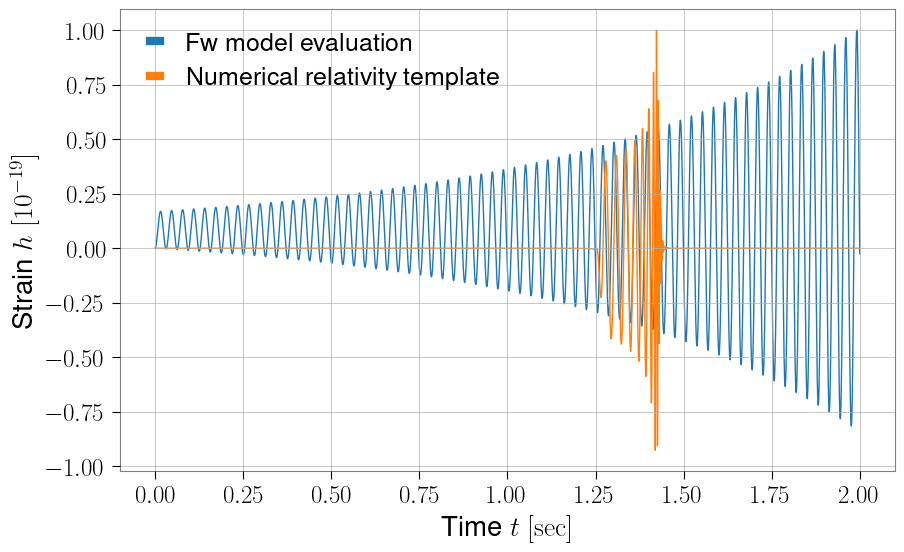

In [5]:

def loss_fn(p, model):
    h = model(p)          # shape (T,)
    return jnp.sum(h**2)  # scalar

# coarse_times = jnp.linspace(gw_times.min(), gw_times.max(), len(gw_times)//10)
coarse_times = gw_times
print("Using coarse_times of length ", len(coarse_times))

omega_cfm, gamma_cfm, xi_cfm = [create_cfm(downsampled_times=coarse_times, prefix=p, offset_std=ofs_std, offset_mean=ofs_m,fluct=flu, llslope=ll, flex=fle) for
                                p,              ofs_std,    ofs_m,      flu,        ll,         fle in [
                                ("omega_cfm_",  (10,10),      200,          (5,5),      (-6,2),    None),
                                ("gamma_cfm_",  (100,100),      1e1,          (5,5),      (4,2),        None),
                                ("xi_cfm_",     (2,2),      1e5,          (5,5),      (-10,2),     None),
                                ]
                            ]

model = AutoDiffEquationSolver(
    prefix="stochastic_diff_equ_",
    reconstruction_times=gw_times,
    cfm_sampling_times=coarse_times,
    omega_cfm=omega_cfm,
    gamma_cfm=gamma_cfm,
    xi_cfm=xi_cfm,
)

key, subkey = jax.random.split(key)
p0 = jft.random_like(subkey, model.domain)
print("gamma_cfm_fluctuations: ", p0["gamma_cfm_fluctuations"])
test = model(p0)

plt.plot(coarse_times, test, label="Fw model evaluation")
plt.plot(gw_times, gw_waveform, label="Numerical relativity template")
usual_plot()

# loss_val, grad = jax.value_and_grad(loss_fn)(p0, model)

# print("Calculated loss: ", loss_val)
# print("Calculated grad: ", grad)

In [6]:
inference = InferenceSchemeRe(t=gw_times, d=gw_waveform, key=key, e_fac=1, r_fac=1, plotting_callback=analyze_kl_callback)
inference.add_noise_op(noise_var_level=.1)
inference.add_custom_signal_model(custom_signal_model=model)

Using DIAGONAL noise operators.


In [ ]:
latent_samples, other_stuff = inference.run_inference(kl_iterations=10, n_samples=15, use_strict_minimizers=False, out_name="sde3", resume=True, choose_low_kl_starting_pos=False, geoVi=True)

/Users/iason/PycharmProjects/STRAIN/nifty/nifty/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
overwriting `position_or_samples` with `resume`
OPTIMIZE_KL: Starting 0007


	Choosing random initial position in parameter space...


CG, linear sampling: Iteration 0 ⛰:+2.2793e+04 Δ⛰:inf ➽:2.0000e-02
CG, linear sampling: Iteration 1 ⛰:-1.2262e+04 Δ⛰:3.5055e+04 ➽:2.0000e-02
CG, linear sampling: Iteration 2 ⛰:-1.2272e+04 Δ⛰:9.8282e+00 ➽:2.0000e-02
CG, linear sampling: Iteration 3 ⛰:-1.2274e+04 Δ⛰:2.5776e+00 ➽:2.0000e-02
CG, linear sampling: Iteration 4 ⛰:-1.2275e+04 Δ⛰:7.9835e-01 ➽:2.0000e-02
CG, linear sampling: Iteration 5 ⛰:-1.2275e+04 Δ⛰:2.0724e-03 ➽:2.0000e-02
CG, linear sampling: Iteration 6 ⛰:-1.2275e+04 Δ⛰:1.7117e-01 ➽:2.0000e-02
CG, linear sampling: Iteration 7 ⛰:-1.2276e+04 Δ⛰:2.3158e-01 ➽:2.0000e-02
CG, linear sampling: Iteration 8 ⛰:-1.2276e+04 Δ⛰:3.9872e-02 ➽:2.0000e-02
CG, linear sampling: Iteration 9 ⛰:-1.2276e+04 Δ⛰:3.6423e-04 ➽:2.0000e-02
CG, linear sampling: Iteration 0 ⛰:-9.3322e+03 Δ⛰:inf ➽:2.0000e-02
CG, linear sampling: Iteration 1 ⛰:-1.1873e+04 Δ⛰:2.5407e+03 ➽:2.0000e-02
CG, linear sampling: Iteration 2 ⛰:-1.2223e+04 Δ⛰:3.5043e+02 ➽:2.0000e-02
CG, linear sampling: Iteration 3 ⛰:-1.2231e+04 Δ⛰:8.

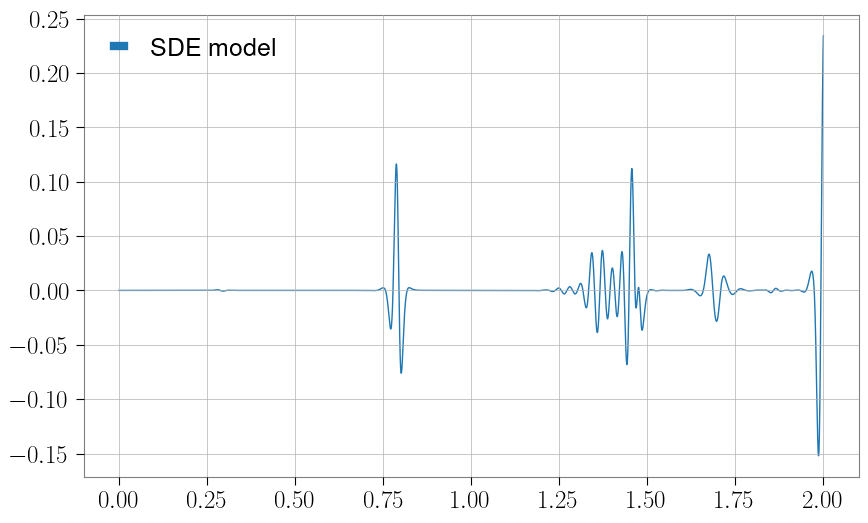

In [34]:
signal_samples = [model(xi) for xi in latent_samples]
signal_mean, signal_std = jft.mean_and_std(signal_samples)

plt.errorbar(coarse_times, signal_mean, yerr=signal_std,label="SDE model", ecolor="lightblue")
# plt.plot(gw_times, gw_waveform, label="GW template")
plt.legend()